<a href="https://colab.research.google.com/github/05ravidubey/Projects_ML/blob/main/Customer_Segmentation_using_K_Means_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
### Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [20]:
### Load Dataset
df = pd.read_csv("/content/Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
### Exploratory Data Analysis(EDA)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [33]:
df.describe()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,0.440000,38.850000,60.560000,50.200000,1.400000
std,0.497633,13.969007,26.264721,25.823522,1.449311
min,0.000000,18.000000,15.000000,1.000000,0.000000
25%,0.000000,28.750000,41.500000,34.750000,0.000000
50%,0.000000,36.000000,61.500000,50.000000,1.000000
75%,1.000000,49.000000,78.000000,73.000000,3.000000
max,1.000000,70.000000,137.000000,99.000000,4.000000


In [6]:
df.shape

(200, 5)

In [7]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [9]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [27]:
df.drop("CustomerID", axis=1, inplace=True)

In [28]:
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})

In [29]:
X = df.copy()

In [30]:
### Doing Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

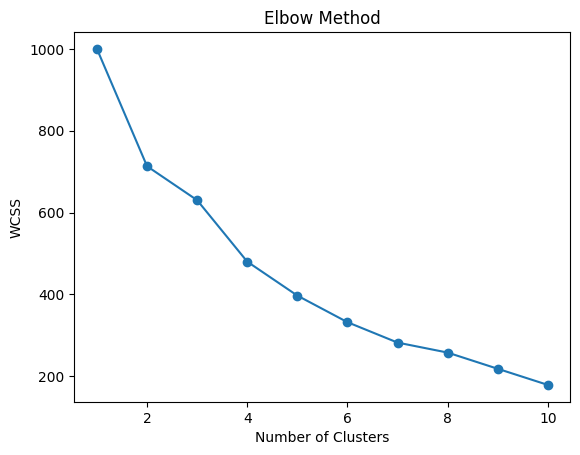

In [31]:
#### Now using elbow ethod to find K
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()


In [14]:
### Now from the above plot we can see that k=5 ( where elbow is bending )

In [21]:
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, Silhouette Score={score}")

k=2, Silhouette Score=0.3973270007887498
k=3, Silhouette Score=0.46658474419000145
k=4, Silhouette Score=0.49434988482196784
k=5, Silhouette Score=0.5546571631111091
k=6, Silhouette Score=0.5138257534676561
k=7, Silhouette Score=0.50200146805547
k=8, Silhouette Score=0.4550112502601921
k=9, Silhouette Score=0.4566624374485964


K wih higheest score is 5 so "k=5"

In [23]:
### Now training the model
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

In [24]:
df["Cluster"] = clusters
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


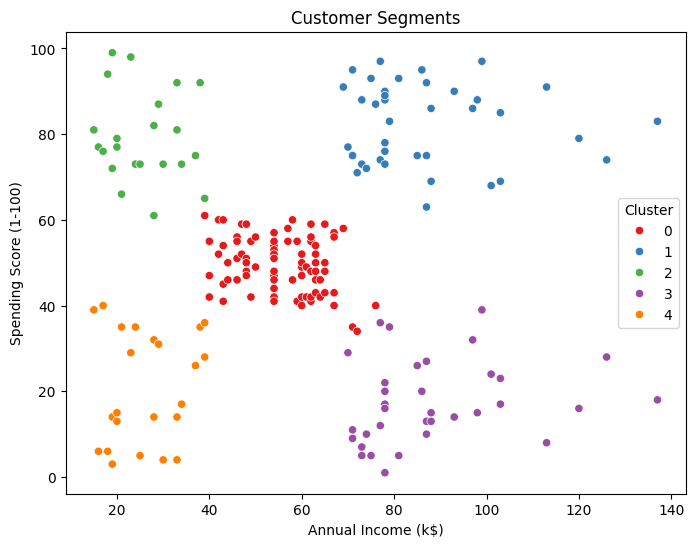

In [16]:
### Showing Clusters
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='Set1'
)

plt.title("Customer Segments")
plt.show()

In [19]:
## Basic Interpretation-  Cluster 0 means  medium income, medium spending, avg customers, Upsell / cross-sell opportunities
## Cluster 1 means High income, high spending → Premium buyers, Most valuable segment, High revenue contributors,Business Action-Loyalty programs and exclusive offers.
## Cluster 2 means Low income, high spending → May not be sustainable, monitor their behaviour
## Cluster 3 means high income, low spending →Imp segment, High income but not spending, Business action-Targeted marketing provide discounts and personalised campaigns.
## Cluster 4 means low income low spending-Avoid heavy marketing



In [32]:
df.groupby("Cluster").mean()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,0.407407,42.716049,55.296296,49.518519
1,0.461538,32.692308,86.538462,82.128205
2,0.409091,25.272727,25.727273,79.363636
3,0.542857,41.114286,88.200000,17.114286
4,0.391304,45.217391,26.304348,20.913043
